<a href="https://colab.research.google.com/github/karinaismayacantik8/JURNAL/blob/main/kanker_paru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. IMPORT LIBRARY**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


**2. LOAD DATSET**

In [ ]:
# =========================================================
# IMPORT LIBRARY
# =========================================================
import pandas as pd


# =========================================================
# LOAD DATASET
# =========================================================
# Pilih salah satu dataset yang akan digunakan

# Dataset 1: Survey Lung Cancer
#df = pd.read_csv("/content/drive/MyDrive/DATASET/survey_lung_cancer.csv")

# Dataset 2: Cancer Patient Dataset
df = pd.read_csv("/content/drive/MyDrive/DATASET/cancer patient data sets.csv")


# =========================================================
# CEK DATA AWAL
# =========================================================
print("Ukuran dataset (baris, kolom):", df.shape)
print("\n5 data teratas:")
print(df.head())

print("\nInformasi dataset:")
print(df.info())


Ukuran dataset (baris, kolom): (1000, 26)

5 data teratas:
   index Patient Id  Age  Gender  Air Pollution  Alcohol use  Dust Allergy  \
0      0         P1   33       1              2            4             5   
1      1        P10   17       1              3            1             5   
2      2       P100   35       1              4            5             6   
3      3      P1000   37       1              7            7             7   
4      4       P101   46       1              6            8             7   

   OccuPational Hazards  Genetic Risk  chronic Lung Disease  ...  Fatigue  \
0                     4             3                     2  ...        3   
1                     3             4                     2  ...        1   
2                     5             5                     4  ...        8   
3                     7             6                     7  ...        4   
4                     7             7                     6  ...        3   

   Weight


Kolom target: Level
Distribusi kelas:
Level
High      365
Medium    332
Low       303
Name: count, dtype: int64
Jumlah baris dan kolom: (1000, 26)

Nama kolom:
['index', 'Patient Id', 'Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy', 'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease', 'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain', 'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath', 'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails', 'Frequent Cold', 'Dry Cough', 'Snoring', 'Level']

Tipe data tiap kolom:
index                        int64
Patient Id                  object
Age                          int64
Gender                       int64
Air Pollution                int64
Alcohol use                  int64
Dust Allergy                 int64
OccuPational Hazards         int64
Genetic Risk                 int64
chronic Lung Disease         int64
Balanced Diet                int64
Obesity               

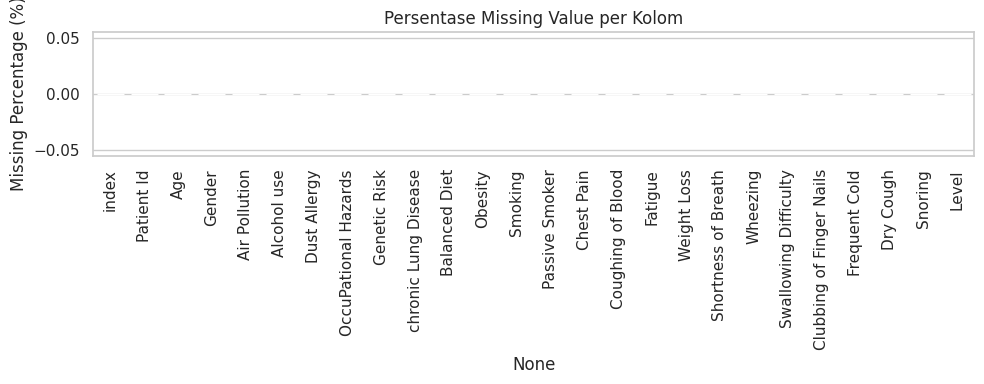


Distribusi kelas target:
Level
High      365
Medium    332
Low       303
Name: count, dtype: int64

Distribusi kelas target (%):
Level
High      36.5
Medium    33.2
Low       30.3
Name: proportion, dtype: float64


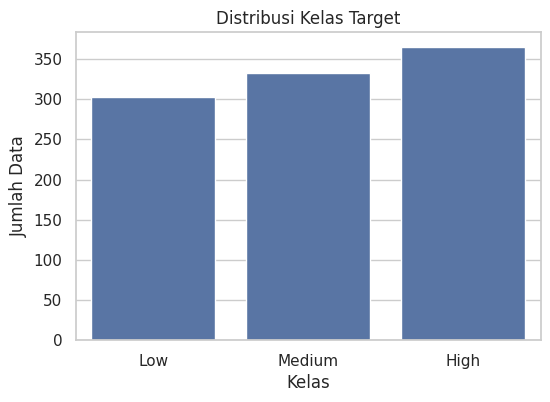

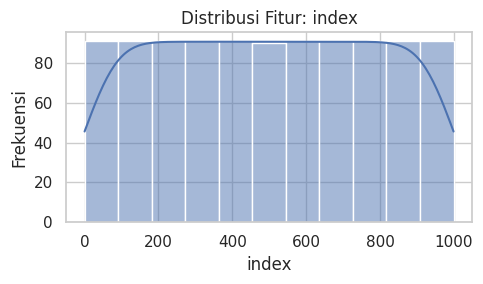

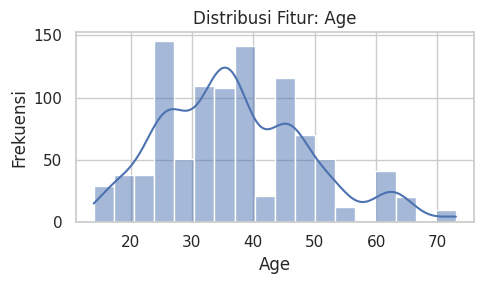

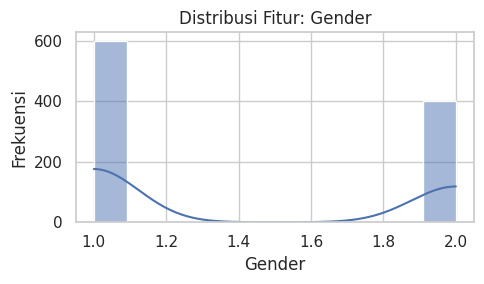

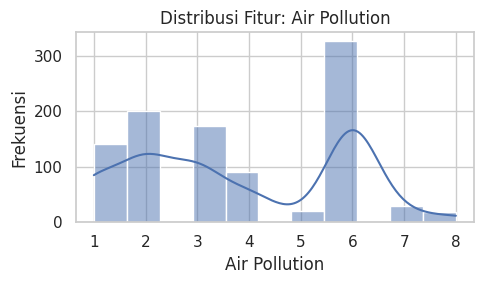

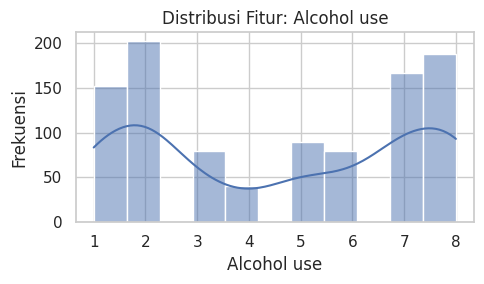

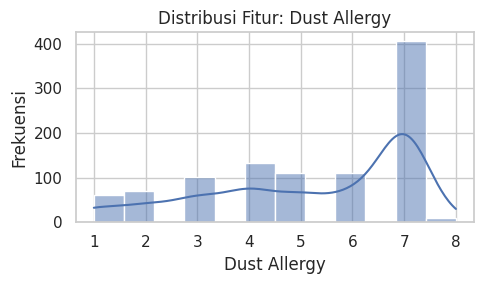

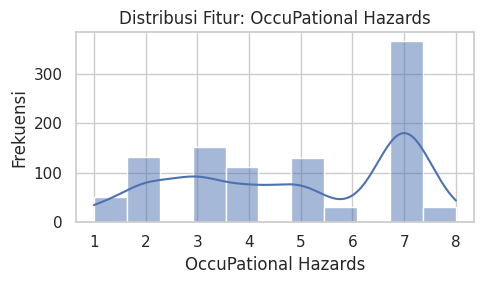

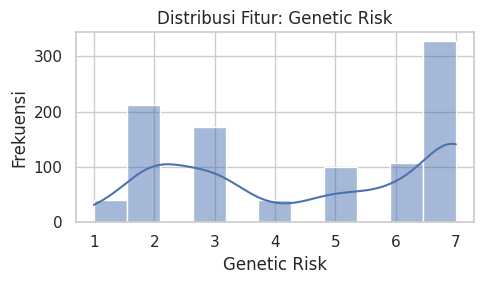

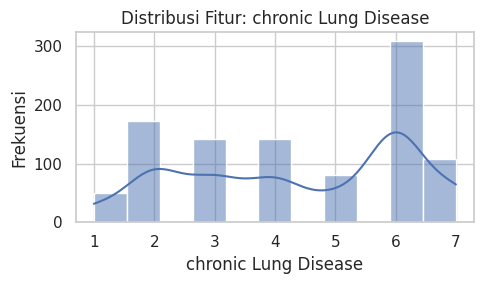

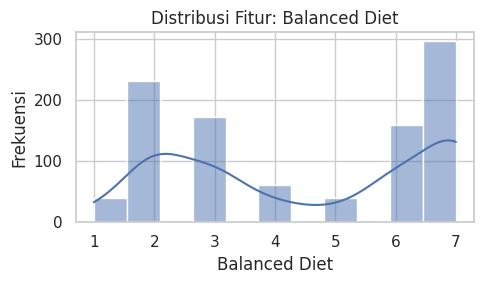

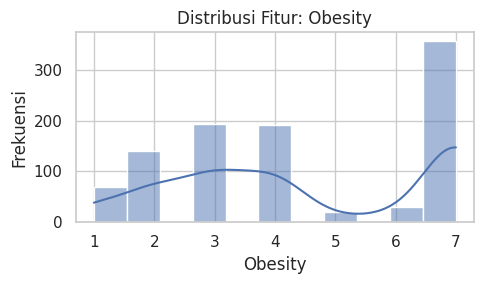

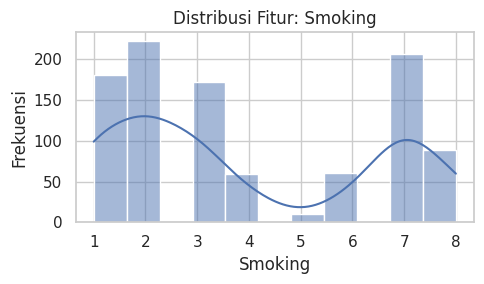

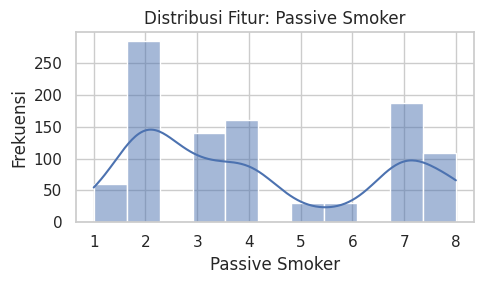

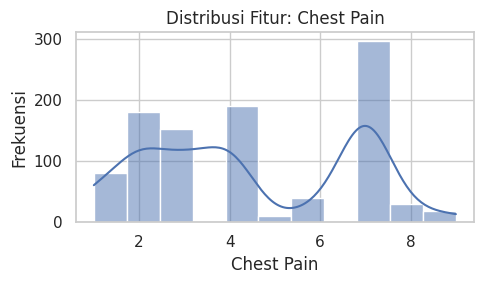

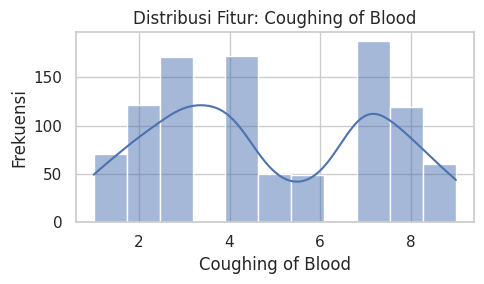

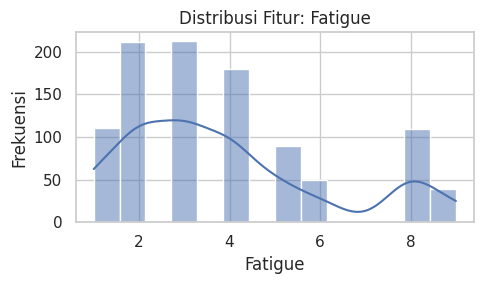

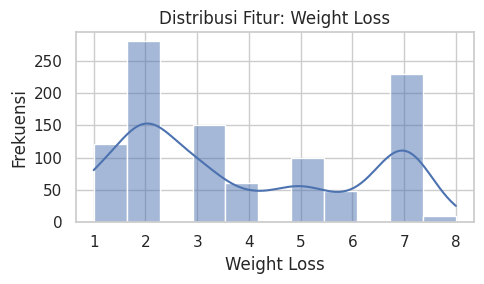

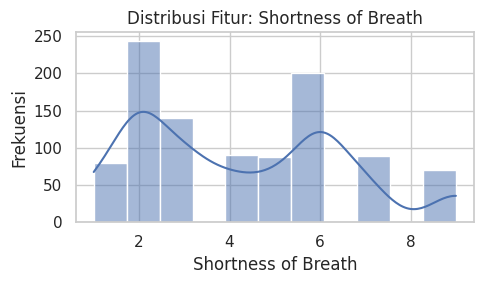

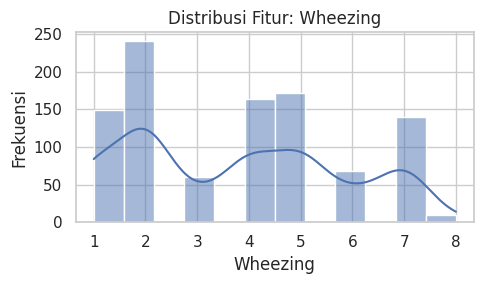

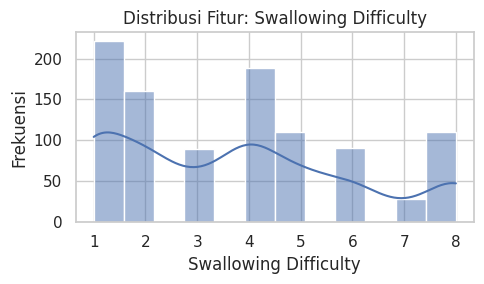

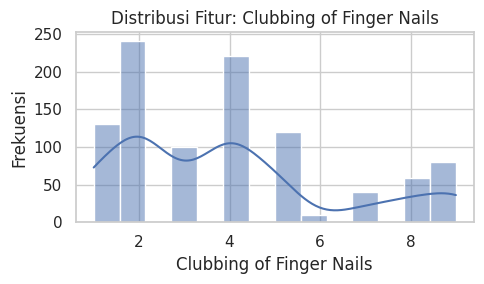

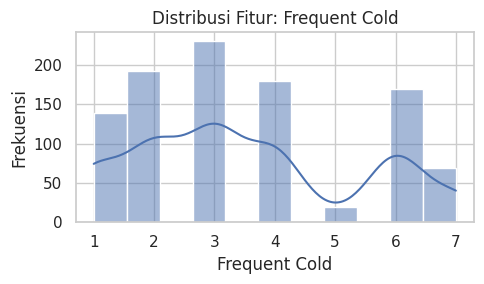

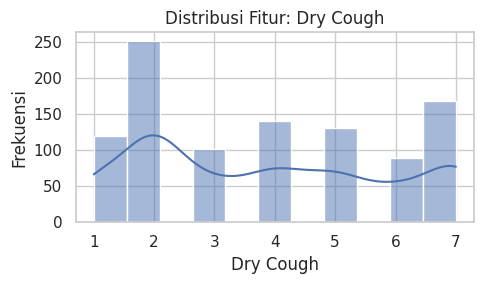

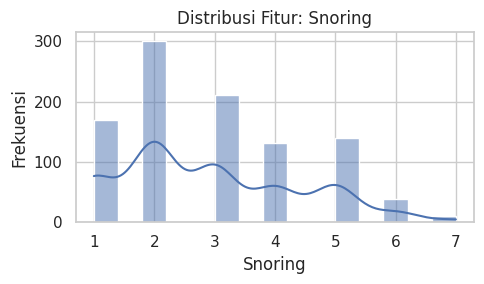

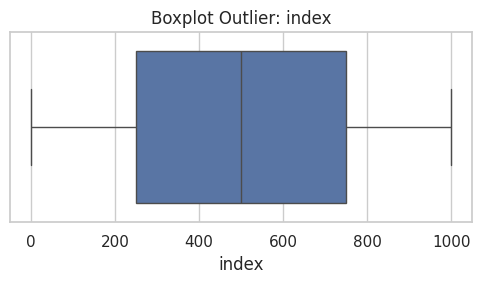

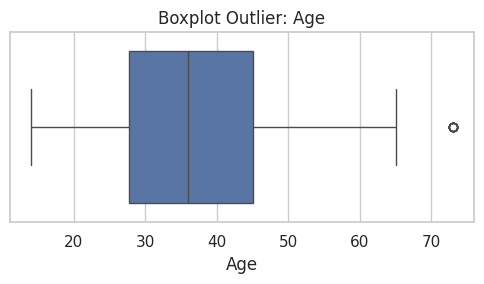

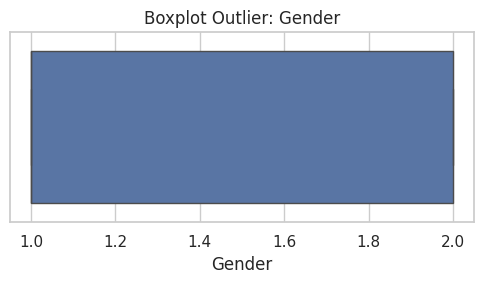

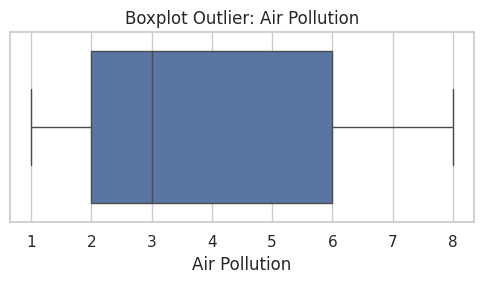

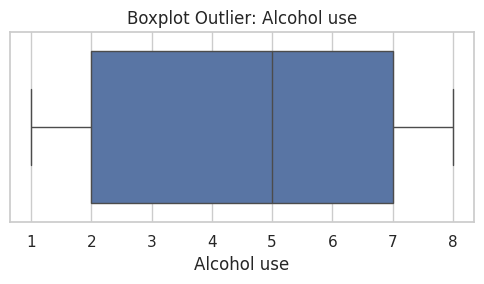

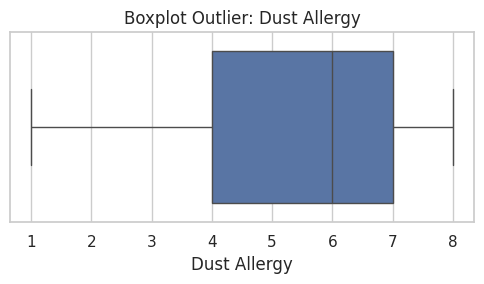

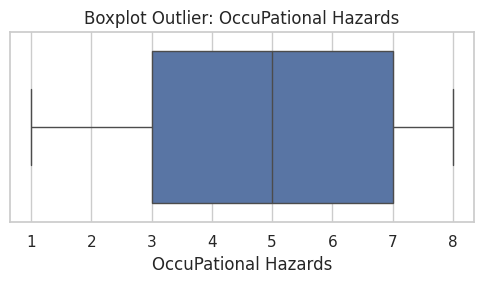

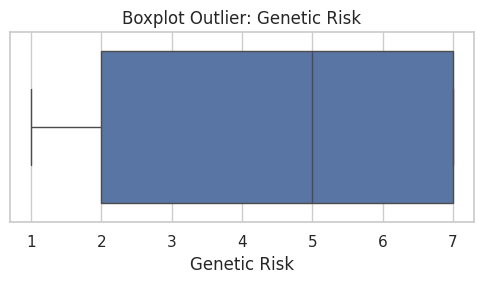

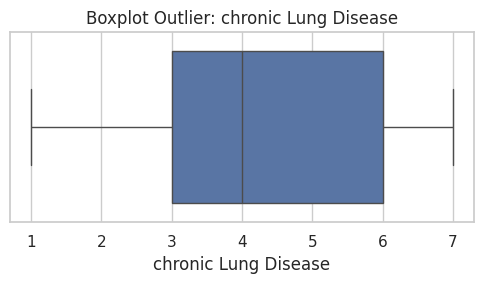

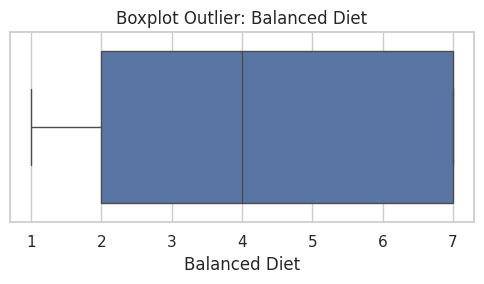

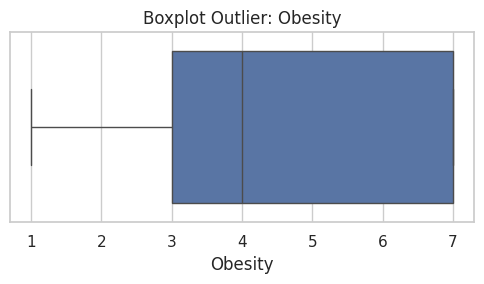

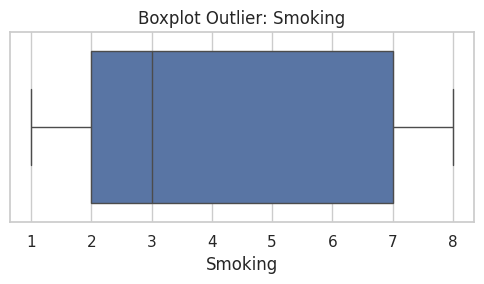

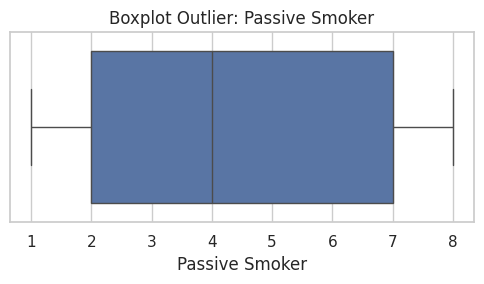

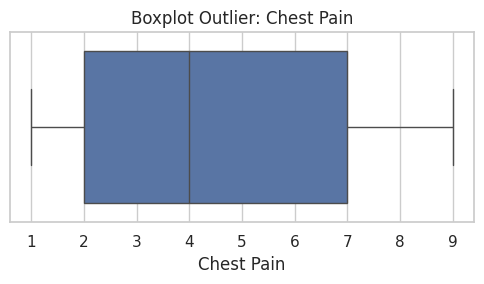

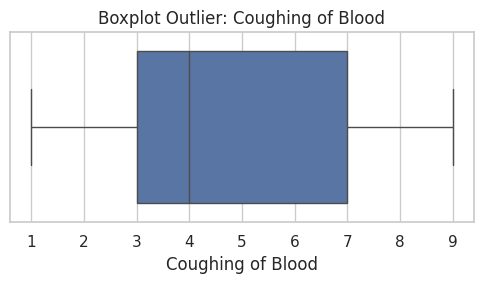

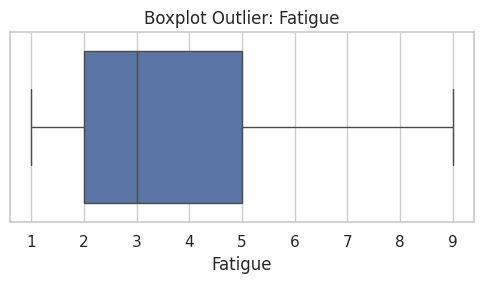

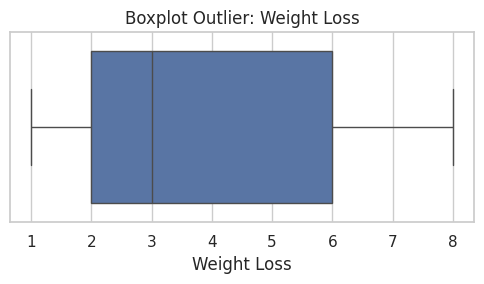

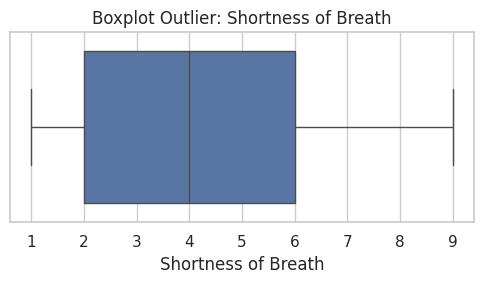

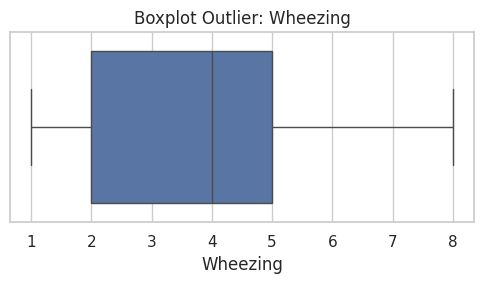

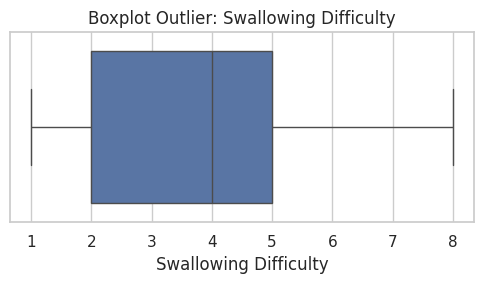

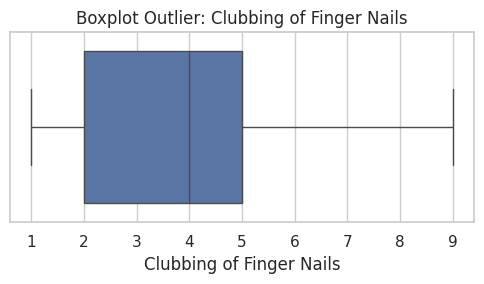

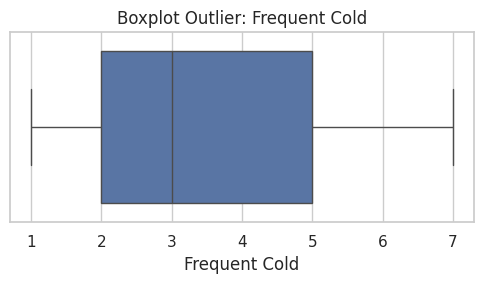

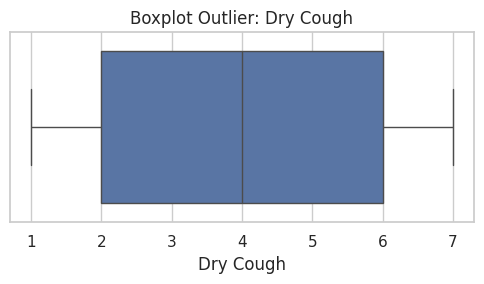

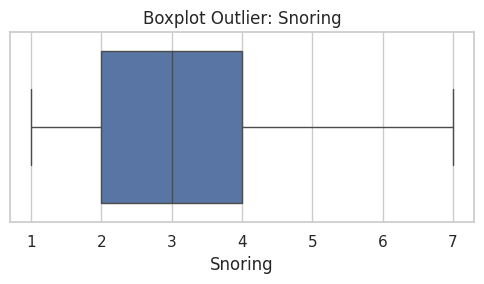

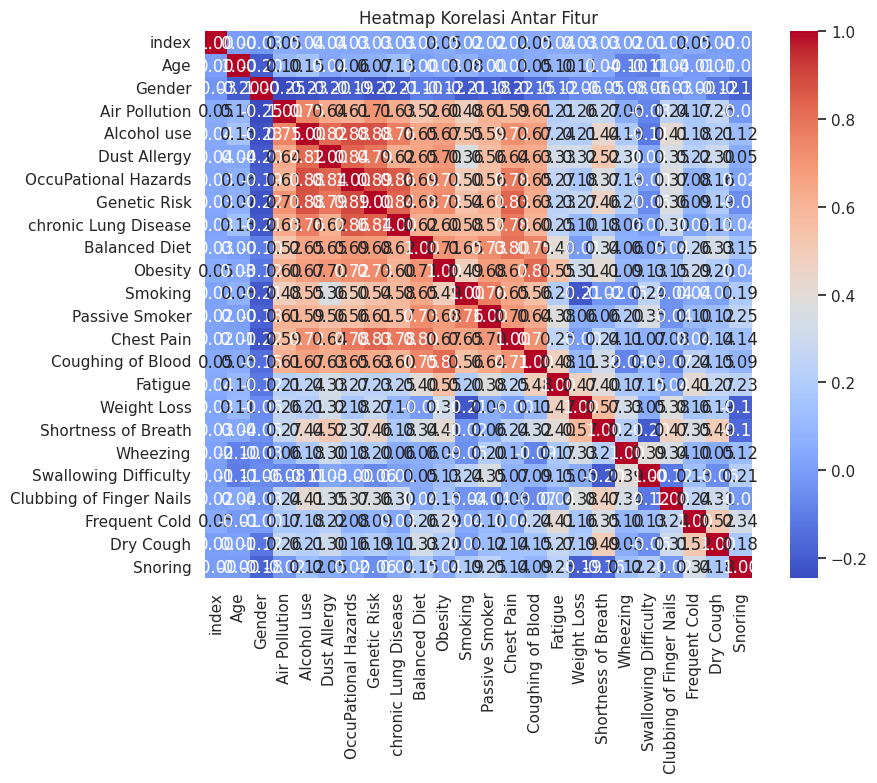

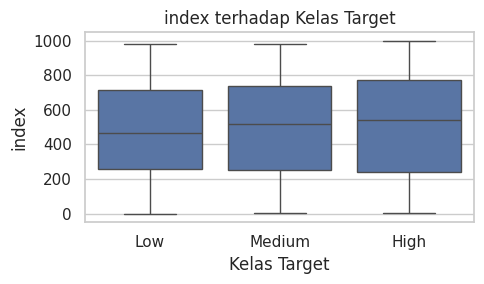

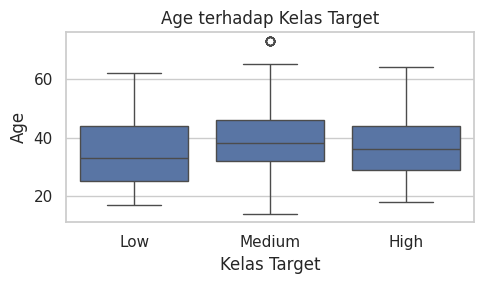

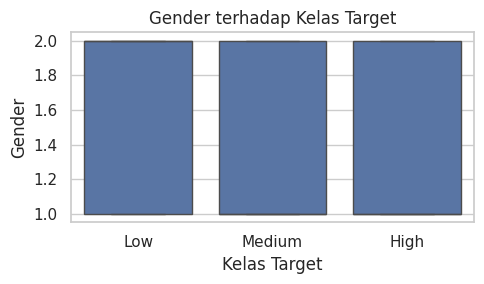

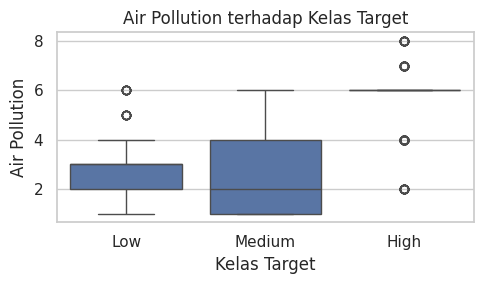

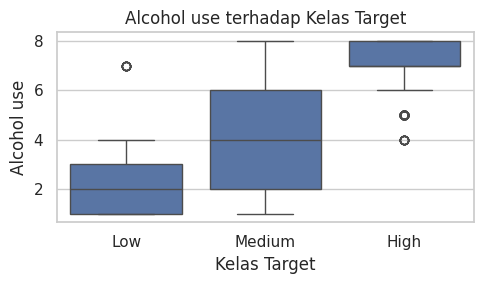

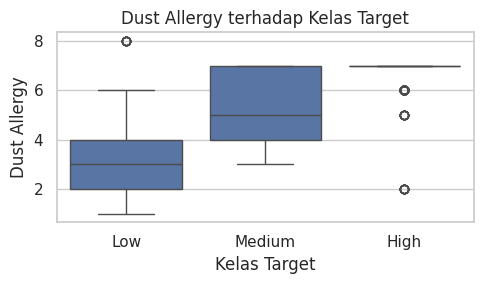

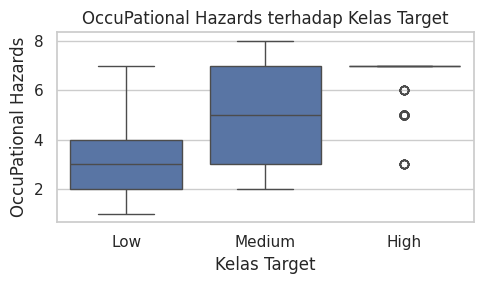

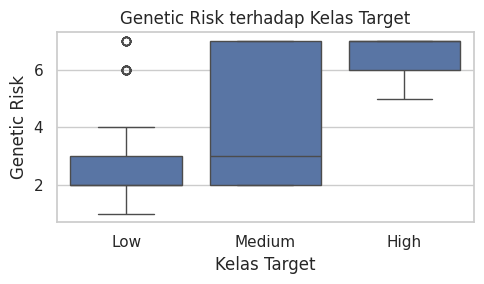

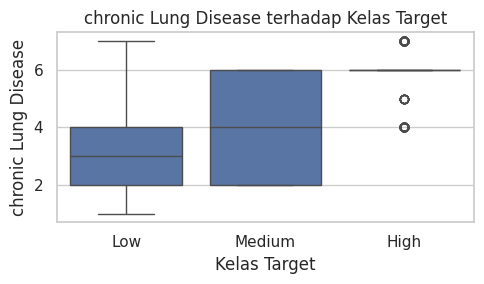

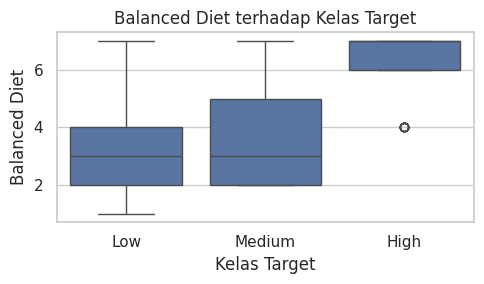

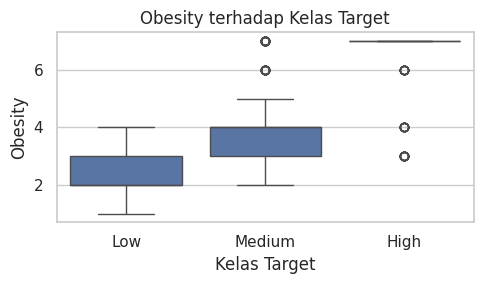

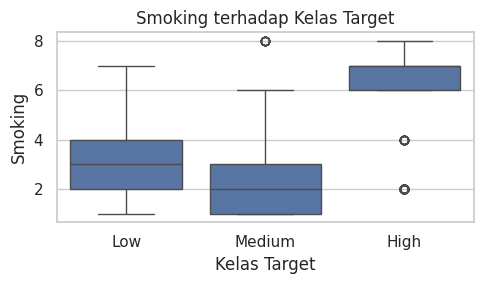

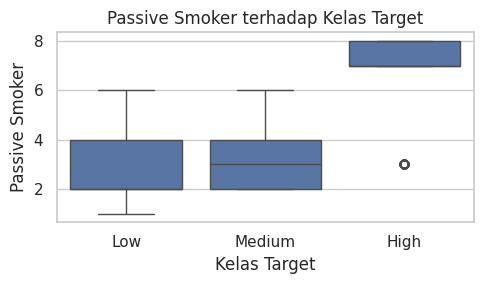

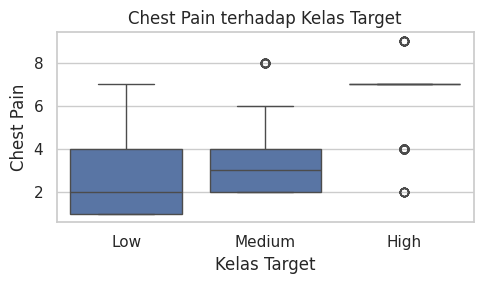

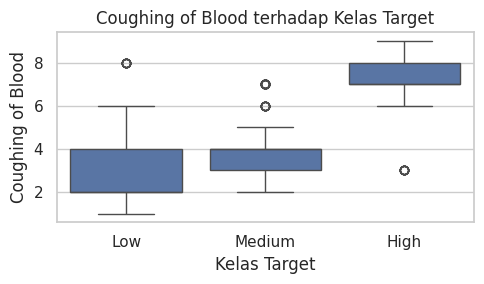

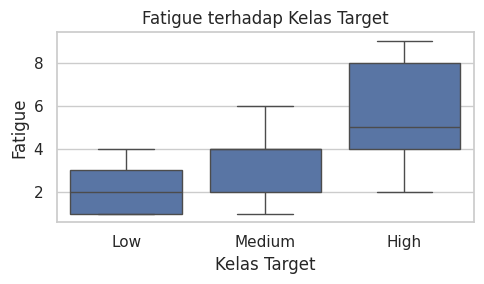

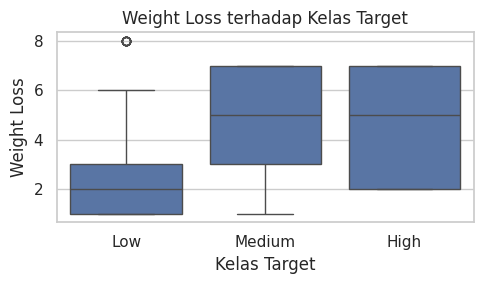

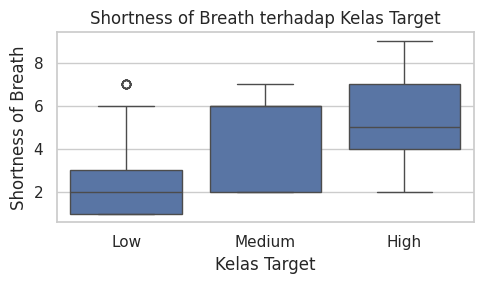

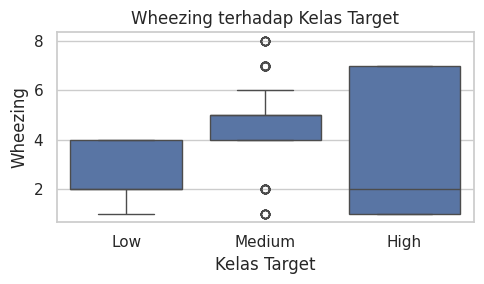

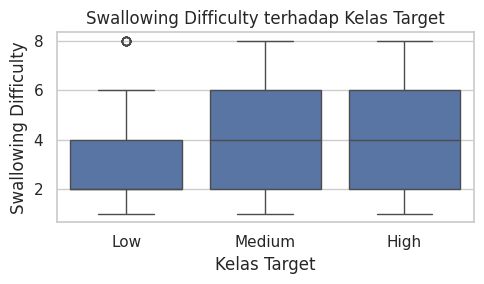

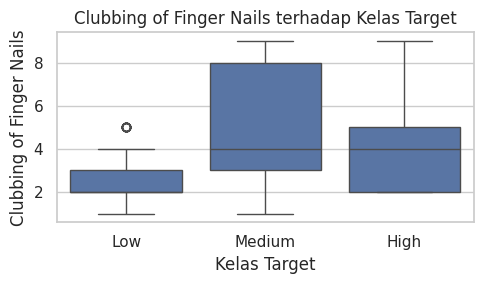

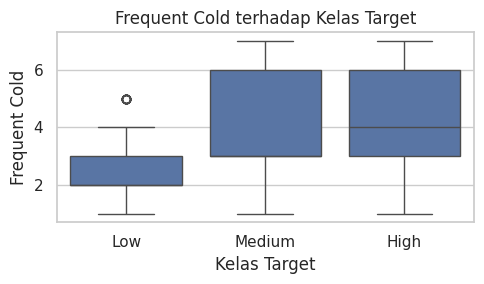

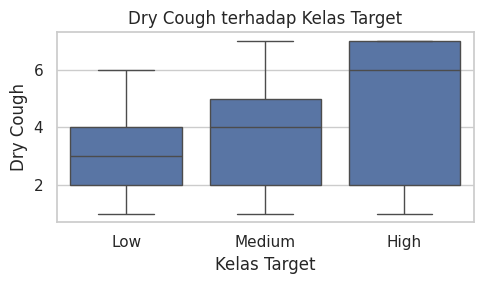

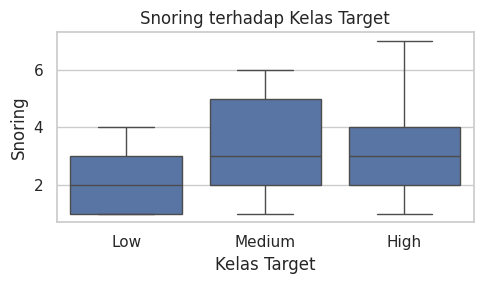


=== RINGKASAN EDA ===
- Dataset telah dianalisis secara statistik dan visual
- Distribusi kelas target telah diperiksa (imbalance / balance)
- Missing value dan potensi outlier telah diidentifikasi
- Korelasi antar fitur dianalisis untuk melihat redundansi
- Hubungan fitur terhadap target telah diamati


In [ ]:
# =========================================================
# MENENTUKAN KOLOM TARGET
# =========================================================
# Untuk dataset Survey Lung Cancer
#target_column = "LUNG_CANCER"

# Jika pakai dataset lain, ganti sesuai kolom labelnya
target_column = "Level"  # contoh


X = df.drop(columns=[target_column])
y = df[target_column]

print("\nKolom target:", target_column)
print("Distribusi kelas:")
print(y.value_counts())


# =========================================================
# EXPLORATORY DATA ANALYSIS (EDA) - LENGKAP
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


# =========================================================
# 1. INFORMASI UMUM DATASET
# =========================================================
print("Jumlah baris dan kolom:", df.shape)
print("\nNama kolom:")
print(df.columns.tolist())


# =========================================================
# 2. TIPE DATA SETIAP KOLOM
# =========================================================
print("\nTipe data tiap kolom:")
print(df.dtypes)


# =========================================================
# 3. STATISTIK DESKRIPTIF
# =========================================================
print("\nStatistik deskriptif fitur numerik:")
print(df.describe())


# =========================================================
# 4. ANALISIS MISSING VALUE
# =========================================================
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage (%)": missing_percent
})

print("\nMissing value tiap kolom:")
print(missing_df)

# Visualisasi missing value
plt.figure(figsize=(10, 4))
sns.barplot(x=missing_df.index, y=missing_df["Missing Percentage (%)"])
plt.xticks(rotation=90)
plt.title("Persentase Missing Value per Kolom")
plt.tight_layout()
plt.show()


# =========================================================
# 5. ANALISIS DISTRIBUSI KELAS (TARGET)
# =========================================================
print("\nDistribusi kelas target:")
print(y.value_counts())

print("\nDistribusi kelas target (%):")
print(y.value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Distribusi Kelas Target")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Data")
plt.show()


# =========================================================
# 6. DISTRIBUSI FITUR NUMERIK
# =========================================================
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns
numeric_columns = numeric_columns.drop(target_column, errors="ignore")

for col in numeric_columns:
    plt.figure(figsize=(5, 3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribusi Fitur: {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.tight_layout()
    plt.show()


# =========================================================
# 7. DETEKSI OUTLIER (BOXPLOT)
# =========================================================
for col in numeric_columns:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot Outlier: {col}")
    plt.tight_layout()
    plt.show()


# =========================================================
# 8. KORELASI ANTAR FITUR
# =========================================================
plt.figure(figsize=(10, 8))
correlation_matrix = df[numeric_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)

plt.title("Heatmap Korelasi Antar Fitur")
plt.tight_layout()
plt.show()


# =========================================================
# 9. HUBUNGAN FITUR TERHADAP TARGET
# =========================================================
for col in numeric_columns:
    plt.figure(figsize=(5, 3))
    sns.boxplot(x=y, y=df[col])
    plt.title(f"{col} terhadap Kelas Target")
    plt.xlabel("Kelas Target")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


# =========================================================
# 10. RINGKASAN TEMUAN EDA (PRINT)
# =========================================================
print("\n=== RINGKASAN EDA ===")
print("- Dataset telah dianalisis secara statistik dan visual")
print("- Distribusi kelas target telah diperiksa (imbalance / balance)")
print("- Missing value dan potensi outlier telah diidentifikasi")
print("- Korelasi antar fitur dianalisis untuk melihat redundansi")
print("- Hubungan fitur terhadap target telah diamati")


**DATA PREPARATION**

In [ ]:
# =========================================================
# DATA PREPARATION
# =========================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# =========================================================
# 1. PISAHKAN FITUR DAN TARGET
# =========================================================
X = df.drop(columns=[target_column])
y = df[target_column]


# =========================================================
# 2. ENCODING LABEL (TARGET)
# =========================================================
# Khusus target (klasifikasi)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)


# =========================================================
# 3. IDENTIFIKASI TIPE FITUR
# =========================================================
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("\nFitur numerik:", list(numeric_features))
print("Fitur kategorikal:", list(categorical_features))


# =========================================================
# 4. PIPELINE PREPROCESSING
# =========================================================

# ---- Pipeline fitur numerik ----
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# ---- Pipeline fitur kategorikal ----
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# ---- Gabungkan preprocessing ----
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)


# =========================================================
# 5. SPLIT DATA (SEBELUM FITTING PREPROCESSOR)
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================================================
# 6. FIT & TRANSFORM DATA
# =========================================================
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print("\nData preparation selesai.")
print("Shape data latih:", X_train_prepared.shape)
print("Shape data uji:", X_test_prepared.shape)



Fitur numerik: ['index', 'Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy', 'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease', 'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain', 'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath', 'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails', 'Frequent Cold', 'Dry Cough', 'Snoring']
Fitur kategorikal: ['Patient Id']

Data preparation selesai.
Shape data latih: (800, 824)
Shape data uji: (200, 824)


**MODELING**

In [ ]:
# =========================================================
# MODELING
# =========================================================

from sklearn.neural_network import MLPClassifier


# =========================================================
# 1. MODELING - BASELINE (ADOPSI JURNAL)
# =========================================================
# Arsitektur sesuai jurnal:
# - 1 hidden layer
# - 50 neuron
# - aktivasi tanh
# - optimizer Adam
# - L2 regularization (alpha = 0.0001)
# - tanpa early stopping
# - tanpa dropout

mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(50,),
    activation="tanh",
    solver="adam",
    learning_rate_init=0.001,
    alpha=0.0001,
    max_iter=1000,
    random_state=42
)

# Latih model baseline
mlp_baseline.fit(X_train_prepared, y_train)


# =========================================================
# 2. MODELING - IMPROVEMENT (EKSPERIMEN)
# =========================================================
# Pengembangan model (tetap dalam tahap Modeling):
# - tambah hidden layer
# - ubah nilai L2
# Preprocessing TIDAK DIUBAH

mlp_improvement = MLPClassifier(
    hidden_layer_sizes=(50, 50),
    activation="tanh",
    solver="adam",
    learning_rate_init=0.001,
    alpha=0.001,
    max_iter=1000,
    random_state=42
)

# Latih model improvement
mlp_improvement.fit(X_train_prepared, y_train)


MLPClassifier(activation='tanh', alpha=0.001, hidden_layer_sizes=(50, 50),
              max_iter=1000, random_state=42)

**EVALUATION**


=== EVALUATION : BASELINE MODEL ===
Accuracy : 0.995
Precision: 0.9950806451612902
Recall   : 0.995
F1-score : 0.9950012412337864

Classification Report (Baseline):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        73
           1       0.98      1.00      0.99        61
           2       1.00      0.98      0.99        66

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       1.00      0.99      1.00       200



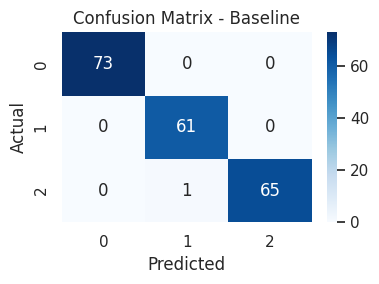


=== EVALUATION : IMPROVEMENT MODEL ===
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification Report (Improvement):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        73
           1       1.00      1.00      1.00        61
           2       1.00      1.00      1.00        66

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



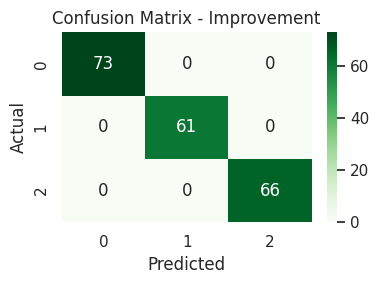


=== PERBANDINGAN PERFORMA MODEL ===
         Model  Accuracy  Precision  Recall  F1-Score
0     Baseline     0.995   0.995081   0.995  0.995001
1  Improvement     1.000   1.000000   1.000  1.000000


In [ ]:
# =========================================================
# EVALUATION
# =========================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# 1. PREDIKSI MODEL
# =========================================================
y_pred_baseline = mlp_baseline.predict(X_test_prepared)
y_pred_improvement = mlp_improvement.predict(X_test_prepared)


# =========================================================
# 2. EVALUASI MODEL BASELINE
# =========================================================
print("\n=== EVALUATION : BASELINE MODEL ===")
print("Accuracy :", accuracy_score(y_test, y_pred_baseline))
print("Precision:", precision_score(y_test, y_pred_baseline, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_baseline, average="weighted"))
print("F1-score :", f1_score(y_test, y_pred_baseline, average="weighted"))

print("\nClassification Report (Baseline):")
print(classification_report(y_test, y_pred_baseline))


# Confusion Matrix Baseline
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(4, 3))
sns.heatmap(cm_baseline, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Baseline")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# =========================================================
# 3. EVALUASI MODEL IMPROVEMENT
# =========================================================
print("\n=== EVALUATION : IMPROVEMENT MODEL ===")
print("Accuracy :", accuracy_score(y_test, y_pred_improvement))
print("Precision:", precision_score(y_test, y_pred_improvement, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred_improvement, average="weighted"))
print("F1-score :", f1_score(y_test, y_pred_improvement, average="weighted"))

print("\nClassification Report (Improvement):")
print(classification_report(y_test, y_pred_improvement))


# Confusion Matrix Improvement
cm_improvement = confusion_matrix(y_test, y_pred_improvement)

plt.figure(figsize=(4, 3))
sns.heatmap(cm_improvement, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - Improvement")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


# =========================================================
# 4. PERBANDINGAN HASIL MODEL
# =========================================================
comparison = pd.DataFrame({
    "Model": ["Baseline", "Improvement"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_improvement)
    ],
    "Precision": [
        precision_score(y_test, y_pred_baseline, average="weighted"),
        precision_score(y_test, y_pred_improvement, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred_baseline, average="weighted"),
        recall_score(y_test, y_pred_improvement, average="weighted")
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_baseline, average="weighted"),
        f1_score(y_test, y_pred_improvement, average="weighted")
    ]
})

print("\n=== PERBANDINGAN PERFORMA MODEL ===")
print(comparison)
